<a href="https://colab.research.google.com/github/zeksrev/DATA601/blob/main/Homework_1_Multi_head_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 1 - Multi-head Attention
Tom Rinkavage
DATA623

Remember, in Chapter 3 we saw:

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a "num_heads" dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec, attn_weights # attn_weights added here to compare with the assignment solution.

## I have added the following verification script to see how it may be used as the above is just the class definition (and we'll need it later).

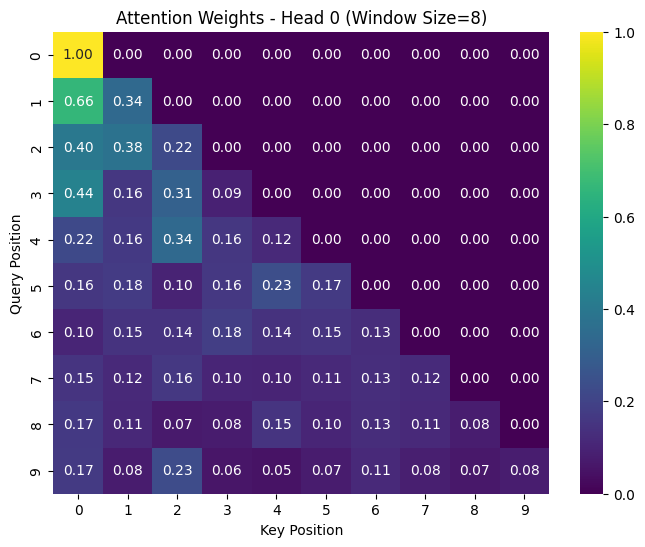

In [2]:
# --- Verification Script ---

# Parameters
d_in = 4
d_out = 4
context_length = 10
dropout = 0.0
num_heads = 2
window_size = 8
batch_size = 1

# Initialize
mha = MultiHeadAttention(d_in, d_out, context_length, dropout, num_heads, window_size)

# Input
torch.manual_seed(42)
x = torch.randn(batch_size, context_length, d_in)

# Forward Pass
context_vec, attn_weights = mha(x)

# Visualization
# We look at the first batch (0) and the first head (0)
head_0_weights = attn_weights[0, 0].detach().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(head_0_weights, cmap="viridis", annot=True, fmt=".2f")
plt.title(f"Attention Weights - Head 0 (Window Size={window_size})")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

# Assignment

## Assignment: The Sliding Window Causal Attention

**Objective:**
In the above block, I have provided you a standard "MultiHeadAttention" implementation that uses a full Causal Mask (autoregressive).

Your task is to modify this class to implement **Sliding Window Causal Attention** (also known as Local Attention).



**The Rules are given below and are IMPORTANT:**
1.  Sliding Window Constraint: A token at position $i$ should only be able to attend to tokens at positions $[i - W, i]$, where $W$ is the "window_size".
2.  Causal Property: The attention must remain causal (tokens cannot look into the future).
3.  Dynamic Masking: The current implementation pre-computes a fixed mask in "__init__". You must remove this and compute the mask **dynamically inside the "forward" pass**. This is necessary because the batch size and number of tokens ("num_tokens") can change during inference, and the mask must adapt to the exact sequence length of the current batch.
4.  Vectorization: You are **forbidden** from using Python "for" loops to iterate over "num_tokens" to build the mask. You must use PyTorch vectorized operations (e.g., "torch.arange", broadcasting, comparison operators).


If your code does not follow these rules, you get ZERO. Nothoing between 5 points or zero. Just ZERO.

To help you get started, I have given partially complete code below.

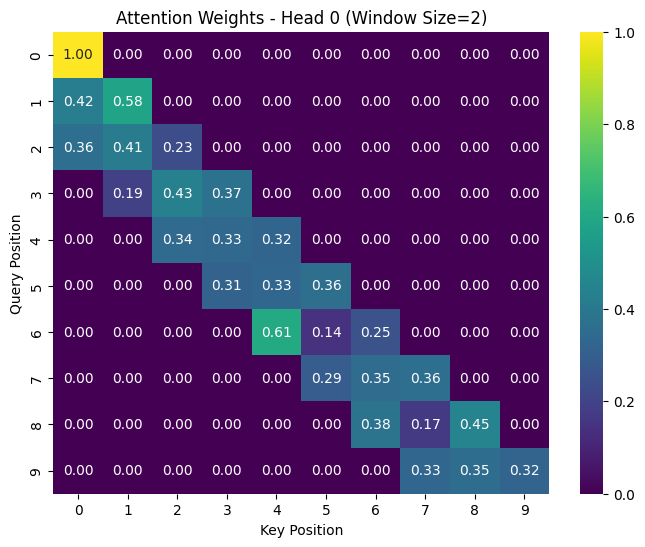

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, window_size, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.window_size = window_size

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)

        # Hint 1: You must remove the static self.register_buffer('mask', ...) from here

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        # --- START OF SOLUTION LOGIC ---                  21:09:28 [55/11828]

        # 1. Create a matrix of indices: [0, 1, 2, ... num_tokens-1]
        # Shape: (num_tokens,)
        indices = torch.arange(num_tokens, device=x.device)

        # 2. Create distance matrix using broadcasting
        # shape: (num_tokens, 1) - (1, num_tokens) -> (num_tokens, num_tokens)
        # distance[i, j] = i - j
        distance = indices.unsqueeze(1) - indices.unsqueeze(0)

        # 3. Define Constraints
        # Causal: distance must be >= 0 (current or past tokens)
        causal_mask = distance < 0

        # Sliding Window: distance must be <= window_size
        # Token i cannot attend to token j if (i - j) > window_size
        window_mask = distance > self.window_size

        # 4. Combine Masks (Union)
        # We want to fill -inf where EITHER mask is True
        mask_bool = causal_mask | window_mask

        # --- END OF SOLUTION LOGIC ---


        # Apply mask
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        # Return weights for visualization purposes (optional, usually we return just context_vec)
        return context_vec, attn_weights

# --- Verification Script (same as above) ---

# Parameters
d_in = 4
d_out = 4
context_length = 10
dropout = 0.0
num_heads = 2
window_size = 2
batch_size = 1

# Initialize
mha = MultiHeadAttention(d_in, d_out, context_length, dropout, num_heads, window_size)

# Input
torch.manual_seed(42)
x = torch.randn(batch_size, context_length, d_in)

# Forward Pass
context_vec, attn_weights = mha(x)

# Visualization
# We look at the first batch (0) and the first head (0)
head_0_weights = attn_weights[0, 0].detach().numpy()

plt.figure(figsize=(8, 6))
sns.heatmap(head_0_weights, cmap="viridis", annot=True, fmt=".2f")
plt.title(f"Attention Weights - Head 0 (Window Size={window_size})")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.show()

#Solution Explanation
I used **ChatGPT 5.4** to produce the missing code for the solution.
My summary of the concept:
So training needs to look only at the past to make prediction of the future valid. A causal mask ensures that transformer attention uses only the current token and previous tokens, not future tokens. This means a model is trained using only past context when learning to predict the next token.




Following is just the image, it does not come out of the above code which is incomplete.

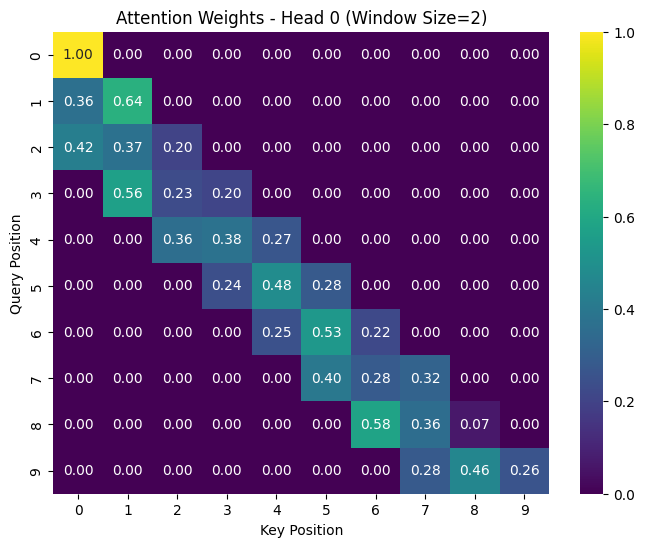

**The Rules are:**
1.  **Sliding Window Constraint:** A token at position $i$ should only be able to attend to tokens at positions $[i - W, i]$, where $W$ is the "window_size".
2.  **Causal Property:** The attention must remain causal (tokens cannot look into the future).
3.  **Dynamic Masking:** The current implementation pre-computes a fixed mask in "__init__". You must remove this and compute the mask **dynamically inside the "forward" pass**. This is necessary because the batch size and number of tokens ("num_tokens") can change during inference, and the mask must adapt to the exact sequence length of the current batch.
4.  **Vectorization:** You are **forbidden** from using Python "for" loops to iterate over "num_tokens" to build the mask. You must use PyTorch vectorized operations (e.g., "torch.arange", broadcasting, comparison operators).

